In [1]:
from bam_utils import *

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split, TensorDataset, IterableDataset
from torch.nn import functional as F
from torch.nn import Module, ModuleList
import itertools

from model_0509_vae_rnn import VAE, LargeIterableDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}.")

Using cuda.


In [13]:
mdir = '/home/zouy1/projects/RNAmod/autoencoder/input/input_wga_7mer_new/mod/'
batch_size=256

#train_list = list(Path(mdir).rglob("label0_data_chunk_*.pt"))
train_list = list(Path(mdir).rglob("*.pt"))

train_dataset = LargeIterableDataset(train_list, 10000000)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

### Diagnostics

In [14]:
import torch
import pandas as pd
from collections import defaultdict
import numpy as np

base_table = np.array(["A", "C", "G", "T"])


def decode_kmers(batch_x):
    """
    batch_x : tensor (B, 7, 10)
    returns : list[str] length B, each a 7‑mer
    """
    onehot   = batch_x[:, :, :4]               # (B,7,4)
    idx_mat  = onehot.argmax(dim=-1).cpu()     # (B,7) integers 0‥3
    kmers = ["".join(base_table[idx_mat[b].numpy()]) for b in range(idx_mat.size(0))]
    return kmers
    
loader = train_loader

# Running aggregates
counts   = defaultdict(int)
sum_feat = defaultdict(lambda: np.zeros(7))
sum_sq   = defaultdict(lambda: np.zeros(7))

for x_batch in loader:              # ignore label if present
    kmers = decode_kmers(x_batch)       # list of 7‑mer strings
    feats = x_batch[:, 3, 4:].numpy()  # central timestep, ONLY numeric features (10‑4 = 6)
    for f, km in zip(feats, kmers):
        counts[km]   += 1
        sum_feat[km] += f
        sum_sq[km]  += f**2

# build dataframe
records = []
for km in counts:
    n   = counts[km]
    mean= sum_feat[km] / n
    var = (sum_sq[km] / n) - mean**2        # per‑feature variance
    records.append({
        "kmer": km,
        "count": n,
        "min_var": var.min(),
        "max_var": var.max(),
        "mean_var": var.mean()
    })

df = pd.DataFrame(records)


reading /home/zouy1/projects/RNAmod/autoencoder/input/input_wga_7mer_new/mod/mod_chunk_2.pt
reading /home/zouy1/projects/RNAmod/autoencoder/input/input_wga_7mer_new/mod/mod_chunk_8.pt
reading /home/zouy1/projects/RNAmod/autoencoder/input/input_wga_7mer_new/mod/mod_chunk_7.pt
reading /home/zouy1/projects/RNAmod/autoencoder/input/input_wga_7mer_new/mod/mod_chunk_6.pt
reading /home/zouy1/projects/RNAmod/autoencoder/input/input_wga_7mer_new/mod/mod_chunk_4.pt
reading /home/zouy1/projects/RNAmod/autoencoder/input/input_wga_7mer_new/mod/mod_chunk_0.pt
reading /home/zouy1/projects/RNAmod/autoencoder/input/input_wga_7mer_new/mod/mod_chunk_5.pt
reading /home/zouy1/projects/RNAmod/autoencoder/input/input_wga_7mer_new/mod/mod_chunk_3.pt
reading /home/zouy1/projects/RNAmod/autoencoder/input/input_wga_7mer_new/mod/mod_chunk_1.pt
reading /home/zouy1/projects/RNAmod/autoencoder/input/input_wga_7mer_new/mod/mod_chunk_9.pt


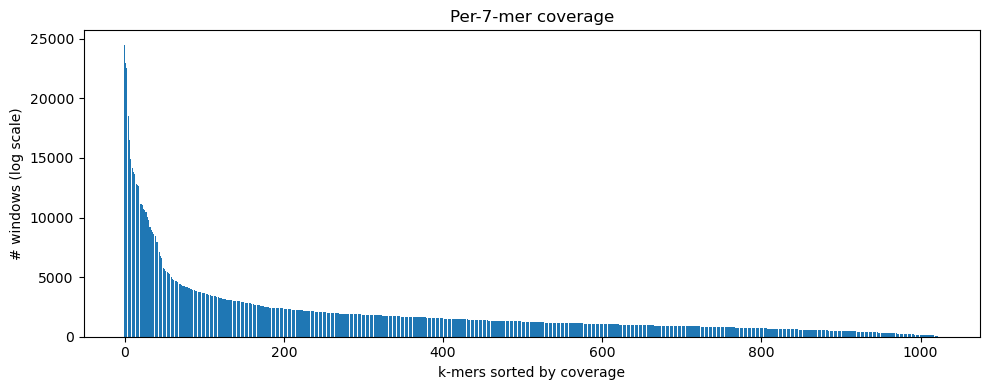

In [15]:
import matplotlib.pyplot as plt

k = 7

# `df` already has one row per k-mer with columns "kmer" and "count"
df_sorted = df.sort_values("count", ascending=False).reset_index(drop=True)

# --- 1. bar-plot of every k-mer count -------------------------------
plt.figure(figsize=(10,4))
plt.bar(df_sorted.index, df_sorted["count"])
#plt.yscale("log")                    # IVT data often spans orders-of-magnitude
plt.xlabel("k-mers sorted by coverage")
plt.ylabel("# windows (log scale)")
plt.title(f"Per-{k}-mer coverage")
plt.tight_layout()
plt.show()


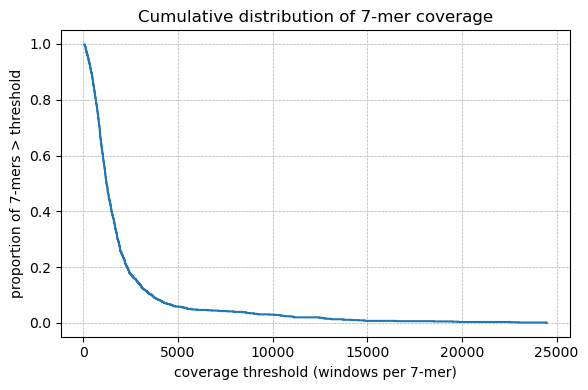

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# assume df["count"] holds the per-k-mer coverage
sort_counts = np.sort(df["count"].values)        # ascending
cum_frac = 1-np.arange(1, len(sort_counts)+1) / len(sort_counts)

plt.figure(figsize=(6,4))
plt.step(sort_counts, cum_frac, where="post")
#plt.xscale("log")                           # log-x helps if counts span decades
plt.xlabel(f"coverage threshold (windows per {k}-mer)")
plt.ylabel(f"proportion of {k}-mers > threshold")
#plt.xlim(0,200)
plt.title(f"Cumulative distribution of {k}-mer coverage")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


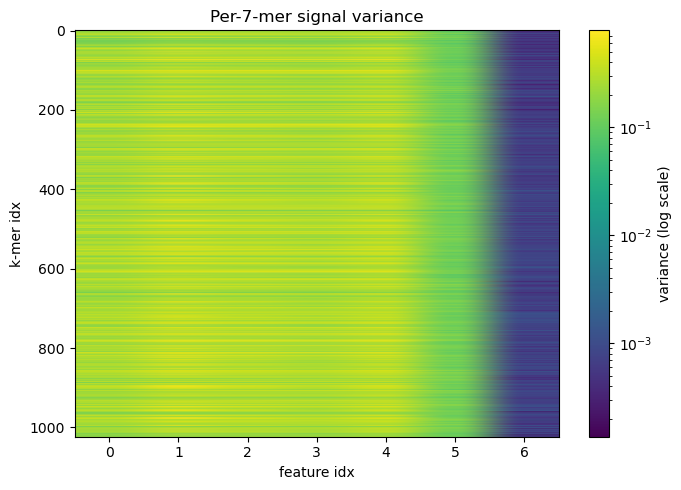

In [17]:
# build variance matrix (kmers × 10 features) for visual inspection
var_matrix = np.stack([ ((sum_sq[km]/counts[km]) - (sum_feat[km]/counts[km])**2)
                        for km in df["kmer"] ])

from matplotlib.colors import LogNorm
eps = 1e-4
var_pos = var_matrix + eps          # shift zeros slightly above 0

plt.figure(figsize=(7,5))
plt.imshow(var_pos,
           aspect="auto",
           cmap="viridis",
           norm=LogNorm(vmin=var_pos.min(), vmax=var_pos.max()))
plt.colorbar(label="variance (log scale)")
plt.xlabel("feature idx")
plt.ylabel("k-mer idx")
plt.title(f"Per-{k}-mer signal variance")
plt.tight_layout()
plt.show()
